  
<div style="background-color:#FCE4EC; padding:25px; border-radius:15px;">

<h1 style="color:#C2185B; text-align:center;">
CodeAlpha Data Science Internship
</h1>

<h2 style="color:#AD1457; text-align:center;">
Task 1: Iris Flower Classification
</h2>

</div>



### Objective

To build and compare machine learning classification models
that predict the species of an Iris flower using sepal and
petal measurements.

### Machine Learning Models

1. Logistic Regression
2. K-Nearest Neighbors
3. Random Forest Classifier

### Technologies

Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

In [5]:
!pip install kagglehub -q


In [6]:
import kagglehub

path = kagglehub.dataset_download("saurabh00007/iriscsv")

print("Dataset path:", path)

100%|██████████| 1.28k/1.28k [00:00<00:00, 613kB/s]

Extracting files...
Dataset path: C:\Users\shaik\.cache\kagglehub\datasets\saurabh00007\iriscsv\versions\1


In [7]:
import os

files = os.listdir(path)

print("Files in dataset folder:")
for file in files:
    print(file)

Files in dataset folder:
Iris.csv


In [8]:
import pandas as pd

csv_files = [file for file in files if file.lower().endswith('.csv')]

print("CSV files:", csv_files)

df = pd.read_csv(os.path.join(path, csv_files[0]))

df.head()

CSV files: ['Iris.csv']


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [9]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.info()

Rows: 150
Columns: 6
<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             150 non-null    int64  
 1   SepalLengthCm  150 non-null    float64
 2   SepalWidthCm   150 non-null    float64
 3   PetalLengthCm  150 non-null    float64
 4   PetalWidthCm   150 non-null    float64
 5   Species        150 non-null    str    
dtypes: float64(4), int64(1), str(1)
memory usage: 9.1 KB


In [10]:
df.describe()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,75.500000,5.843333,3.054000,3.758667,1.198667
std,43.445368,0.828066,0.433594,1.764420,0.763161
min,1.000000,4.300000,2.000000,1.000000,0.100000
25%,38.250000,5.100000,2.800000,1.600000,0.300000
50%,75.500000,5.800000,3.000000,4.350000,1.300000
75%,112.750000,6.400000,3.300000,5.100000,1.800000
max,150.000000,7.900000,4.400000,6.900000,2.500000


In [11]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
Id               0
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64


In [12]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [13]:
if 'Id' in df.columns:
    df = df.drop('Id', axis=1)

df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [14]:
print(df['Species'].value_counts())

Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


Matplotlib is building the font cache; this may take a moment.


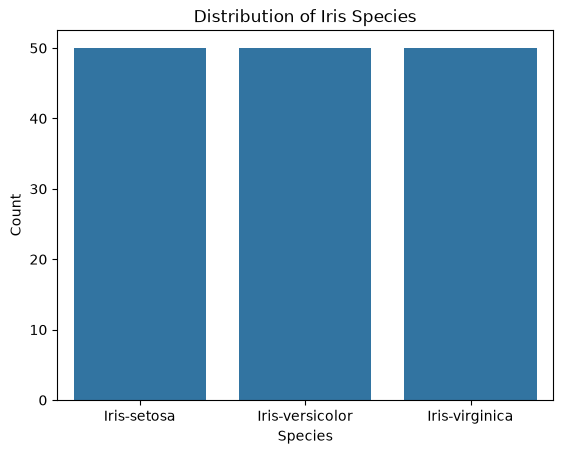

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='Species')

plt.title("Distribution of Iris Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

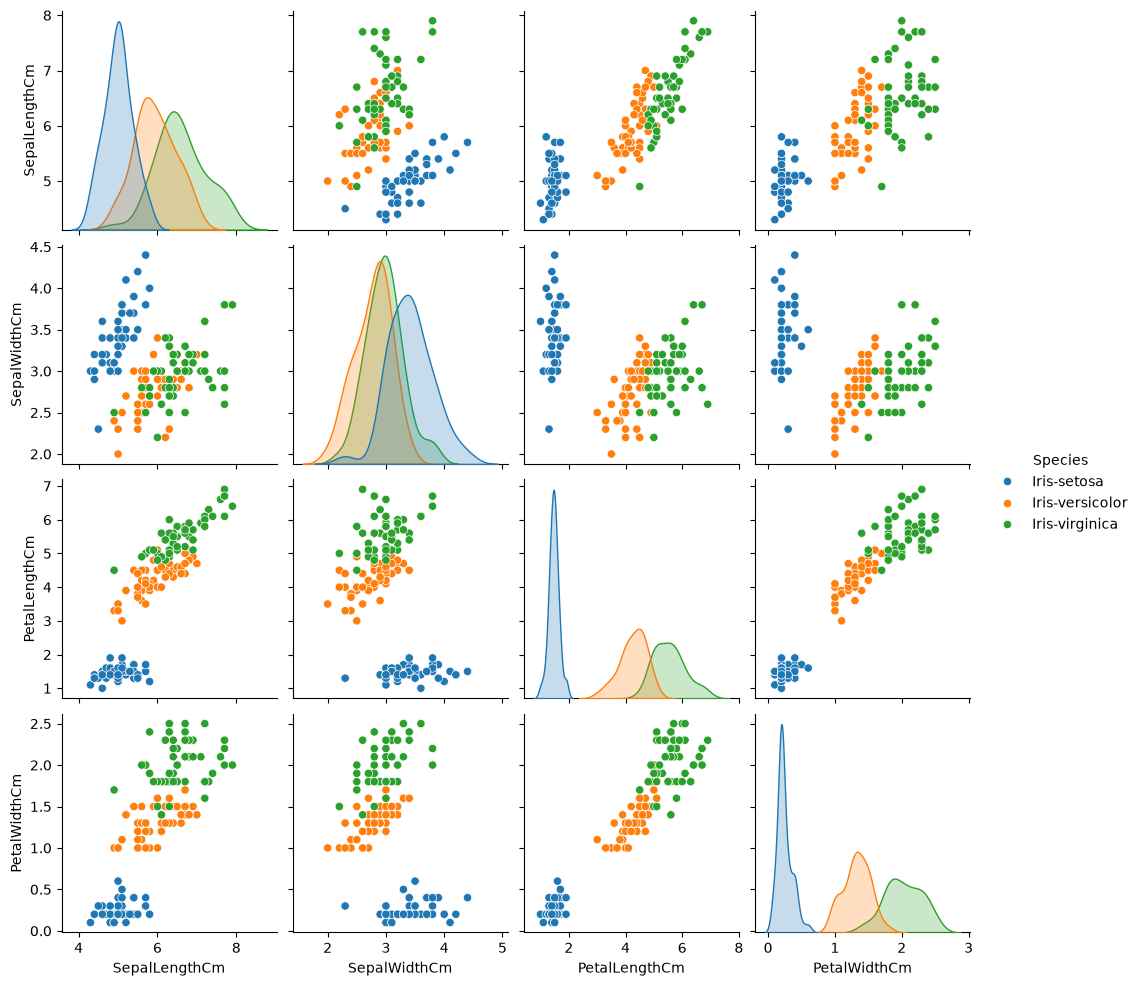

In [16]:
sns.pairplot(df, hue='Species')

plt.show()

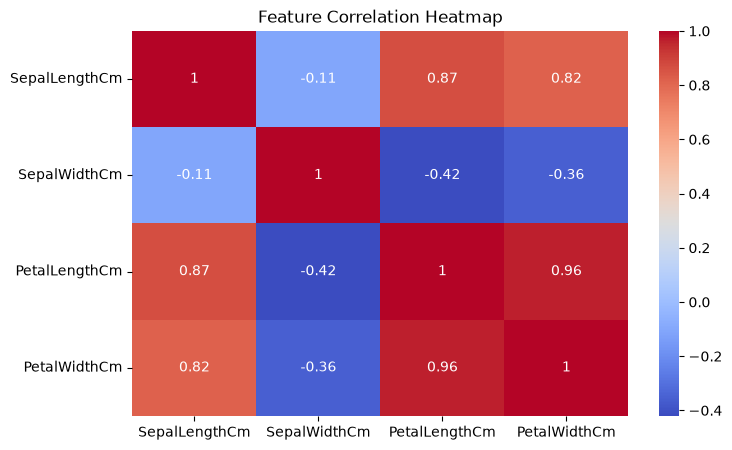

In [17]:
numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(8, 5))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Feature Correlation Heatmap")

plt.show()

In [18]:
X = df.drop('Species', axis=1)
y = df['Species']

print("Features:")
print(X.columns)

print("\nTarget:")
print(y.name)

Features:
Index(['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'], dtype='str')

Target:
Species


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 120
Testing samples: 30


## Model 1 — Logistic Regression

In [20]:
from sklearn.linear_model import LogisticRegression

logistic_model = LogisticRegression(max_iter=200)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)

In [21]:
from sklearn.metrics import accuracy_score

logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

print("Logistic Regression Accuracy:",
      logistic_accuracy * 100, "%")

Logistic Regression Accuracy: 96.66666666666667 %


## Model 2 — KNN

In [22]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)

knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)

In [23]:
knn_accuracy = accuracy_score(
    y_test,
    knn_pred
)

print("KNN Accuracy:",
      knn_accuracy * 100, "%")

KNN Accuracy: 100.0 %


## Model 3 — Random Forest

In [24]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [25]:
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

print("Random Forest Accuracy:",
      rf_accuracy * 100, "%")

Random Forest Accuracy: 90.0 %


## 📊 Model Comparison

In [26]:
comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'KNN',
        'Random Forest'
    ],
    'Accuracy': [
        logistic_accuracy,
        knn_accuracy,
        rf_accuracy
    ]
})

comparison['Accuracy (%)'] = comparison['Accuracy'] * 100

comparison

,Model,Accuracy,Accuracy (%)
0,Logistic Regression,0.966667,96.666667
1,KNN,1.000000,100.000000
2,Random Forest,0.900000,90.000000


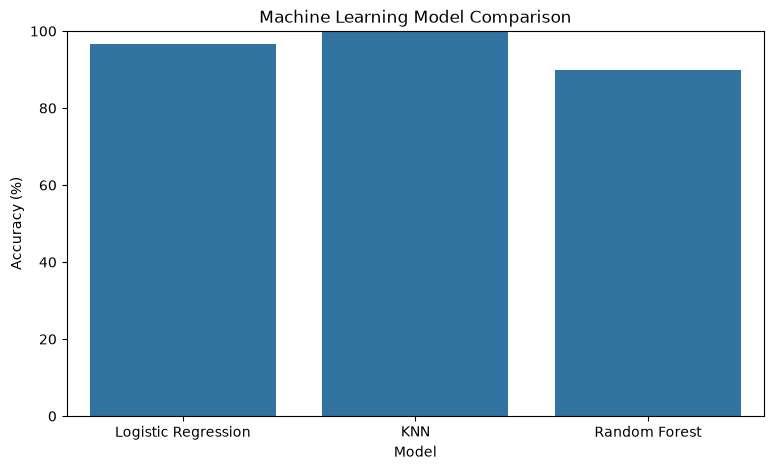

In [27]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=comparison,
    x='Model',
    y='Accuracy (%)'
)

plt.title("Machine Learning Model Comparison")
plt.ylabel("Accuracy (%)")
plt.xlabel("Model")

plt.ylim(0, 100)

plt.show()

## Confusion Matrix

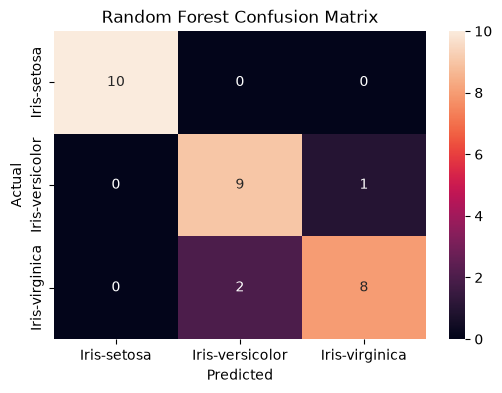

In [29]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=rf_model.classes_,
    yticklabels=rf_model.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Random Forest Confusion Matrix")

plt.show()

## Classification Report

In [30]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        rf_pred
    )
)

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



## 🌸 New Flower Prediction

In [31]:
sample_flower = [[
    5.1,
    3.5,
    1.4,
    0.2
]]

prediction = rf_model.predict(sample_flower)

print("Predicted Iris Species:", prediction[0])

Predicted Iris Species: Iris-setosa


C:\Users\shaik\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


   
<div style="background-color:#FCE4EC; padding:25px; border-radius:15px;">

<h1 style="color:#C2185B; text-align:center;">
Conclusion
</h1>

<p style="color:#4A1730; font-size:16px; line-height:1.7; text-align:justify;">
Three machine learning classification models were developed
for Iris flower species prediction: Logistic Regression,
K-Nearest Neighbors and Random Forest.
</p>

<p style="color:#4A1730; font-size:16px; line-height:1.7; text-align:justify;">
The models were evaluated using classification accuracy and
the results were compared. Random Forest was further evaluated
using a confusion matrix and classification report.
</p>

<p style="color:#4A1730; font-size:16px; line-height:1.7; text-align:justify;">
The project demonstrates how machine learning can classify
flower species based on sepal and petal measurements.
</p>

</div>


 <div style="background-color:#E0F7FA; padding:25px; border-radius:15px;">

<h1 style="color:#0277BD; text-align:center;">
Skills Demonstrated
</h1>

<ul style="color:#164E63; font-size:16px; line-height:1.8;">

<li>Python Programming</li>
<li>Pandas</li>
<li>NumPy</li>
<li>Data Cleaning</li>
<li>Exploratory Data Analysis</li>
<li>Data Visualization</li>
<li>Classification</li>
<li>Machine Learning</li>
<li>Model Comparison</li>
<li>Confusion Matrix</li>
<li>Model Evaluation</li>

</ul>

</div>